In [1]:
import scipy.io
import numpy as np
import pandas as pd
from pathlib import Path
import gymnasium as gym
from gymnasium import spaces
from sb3_contrib import RecurrentPPO
from stable_baselines3 import PPO
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from stable_baselines3.common.env_checker import check_env
import pandas as pd
from pathlib import Path
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from stable_baselines3 import PPO
from stable_baselines3 import DDPG # Ganti PPO ke DDPG
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.evaluation import evaluate_policy
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from stable_baselines3 import PPO
from stable_baselines3 import DDPG, TD3
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.evaluation import evaluate_policy
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
from sklearn.metrics import mean_squared_error, r2_score
from sb3_contrib import TRPO
print("INFO: Import Library")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


INFO: Import Library


# Load Dataset

In [2]:
# Function to load mat file
def load_mat_file(file_path):
    path =Path(file_path)
    try:
        mat = scipy.io.loadmat(path)
        if 'meas' not in mat:
            print(f"ERROR: Key 'meas' is not found in {path.name}")
            return None
        
        data_struct = mat["meas"][0,0]
        names = data_struct.dtype.names
        raw_data = {}
        for name in names:
            content = data_struct[name].flatten()
            
            if len(content) > 0 and isinstance(content[0], np.ndarray):
                raw_data[name] = content[0].flatten()
            else:
                raw_data[name] = content
            
        lengths = [len(v) for v in raw_data.values() if isinstance(v, (np.ndarray, list))]
        max_len = max(lengths) if lengths else 1

        final_data = {}
        for name, values in raw_data.items():
            curr_len = len(values) if isinstance(values, (np.ndarray, list)) else 1
            
            if curr_len != max_len:
                single_val = values[0] if curr_len > 0 else np.nan
                if hasattr(single_val, 'decode'):
                    single_val = single_val.decode('utf-8')
                final_data[name] = [single_val] * max_len
            else:
                if isinstance(values, np.ndarray) and values.dtype.kind in ['S', 'V']:
                    final_data[name] = [v.decode('utf-8') if hasattr(v, 'decode') else v for v in values]
                else:
                    final_data[name] = values

        df = pd.DataFrame(final_data)
        return df


    except Exception as e:
        print(f"ERROR: Failed to load {path.name}. {e}")

In [3]:
# Load dataset into df_master
base_path = Path('datasets/1-Open Data')

all_dfs = []

for file_path in base_path.rglob('*.mat'):
    try:
        print(f'INFO: System is processing to load {file_path}')
        df_temp = load_mat_file(str(file_path))
        
        df_temp['Session_ID'] = file_path 
        df_temp['SOC_lag_1'] = df_temp['SOC'].shift(1)
        df_temp = df_temp.dropna(subset=['SOC_lag_1'])
        
        all_dfs.append(df_temp)
        print(f"INFO: Success to load {file_path}")
        
    except Exception as e:
        print(f"ERROR: Failed to load {file_path}: {e}")

df_master = pd.concat(all_dfs, ignore_index=True)
df_master = df_master.drop(columns=[
    'TimeStamp', 
    'Time', 
    'Battery_Temp_degC', 
    'Ambient_Temp_degC', 
    'Cycle_Label', 
    'Test_Cell', 
    # 'Session_ID'
    ])
df_master.sample(5)

INFO: System is processing to load datasets/1-Open Data/m1000/40C/Drive Cycles/20_REORDERED6_05-17-21_13.21 Tesla_40C_DriveCycles_Ch4.mat
INFO: Success to load datasets/1-Open Data/m1000/40C/Drive Cycles/20_REORDERED6_05-17-21_13.21 Tesla_40C_DriveCycles_Ch4.mat
INFO: System is processing to load datasets/1-Open Data/m1000/40C/Drive Cycles/30_HWGRADE1_05-21-21_01.47 Tesla_40C_DriveCycles_Ch4.mat
INFO: Success to load datasets/1-Open Data/m1000/40C/Drive Cycles/30_HWGRADE1_05-21-21_01.47 Tesla_40C_DriveCycles_Ch4.mat
INFO: System is processing to load datasets/1-Open Data/m1000/40C/Drive Cycles/22_REORDERED7_05-18-21_05.14 Tesla_40C_DriveCycles_Ch4.mat
INFO: Success to load datasets/1-Open Data/m1000/40C/Drive Cycles/22_REORDERED7_05-18-21_05.14 Tesla_40C_DriveCycles_Ch4.mat
INFO: System is processing to load datasets/1-Open Data/m1000/40C/Drive Cycles/17_CC_CV_charge_05-16-21_06.54 Tesla_40C_DriveCycles_Ch4.mat
INFO: Success to load datasets/1-Open Data/m1000/40C/Drive Cycles/17_CC_CV_

,Voltage,Current,Ah,SOC,Power,Wh,Session_ID,SOC_lag_1
7450264,4.162256,0.000000,0.000000,1.000000,0.000000,0.000000,datasets/1-Open Data/m1000/0C/Drive Cycles/25_...,1.000000
22933829,4.162200,0.000000,-0.007000,1.001638,0.000000,-1.877000,datasets/1-Open Data/m80/0C/Drive Cycles/21_CC...,1.001638
3453971,3.576912,0.222887,3.571398,0.156298,0.797249,12.692625,datasets/1-Open Data/m1000/-20C/Characterizati...,0.156283
5017492,4.158488,0.000000,0.000700,0.999837,0.000000,0.000000,datasets/1-Open Data/m1000/-10C/Characterizati...,0.999837
9719587,4.066911,3.150530,1.436702,0.687274,12.812925,4.724786,datasets/1-Open Data/m448-N/40C/Drive Cycles/1...,0.687079


# Reinforcement Learning

In [5]:
df_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 24414248 entries, 0 to 24414247
Data columns (total 8 columns):
 #   Column      Dtype  
---  ------      -----  
 0   Voltage     float64
 1   Current     float64
 2   Ah          float64
 3   SOC         float64
 4   Power       float64
 5   Wh          float64
 6   Session_ID  object 
 7   SOC_lag_1   float64
dtypes: float64(7), object(1)
memory usage: 1.5+ GB


In [14]:
df_master = df_master[df_master['SOC'] >=0 ]

In [15]:
features = ['Voltage', 'Current', 'Ah', 'Power', 'Wh']

scaler = MinMaxScaler()
df_master[features] = scaler.fit_transform(df_master[features])

sessions = df_master['Session_ID'].unique()
train_sessions = sessions[:int(0.8 * len(sessions))]
test_sessions = sessions[int(0.8 * len(sessions)):]

df_train = df_master[df_master['Session_ID'].isin(train_sessions)].reset_index(drop=True)
df_test = df_master[df_master['Session_ID'].isin(test_sessions)].reset_index(drop=True)

In [17]:
class BatteryEnv(gym.Env):
    def __init__(self, df):
        super(BatteryEnv, self).__init__()
        self.df = df
        self.sessions = df['Session_ID'].unique()
        
        self.action_space = spaces.Box(low=0.0, high=1.0, shape=(1,), dtype=np.float32)
        
        self.observation_space = spaces.Box(
            low=-np.inf, 
            high=np.inf, 
            shape=(len(features),), 
            dtype=np.float32
        )

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        session_id = np.random.choice(self.sessions)
        self.episode_data = self.df[self.df['Session_ID'] == session_id].reset_index(drop=True)
        self.current_step = 0
        return self._get_obs(), {}

    def _get_obs(self):
        row = self.episode_data.iloc[self.current_step]
        return np.array(row[features].values, dtype=np.float32)

    def step(self, action):
        target_soc = self.episode_data.iloc[self.current_step]['SOC']
        
        reward = -abs(action[0] - target_soc)
        
        self.current_step += 1
        terminated = self.current_step >= len(self.episode_data) - 1
        
        obs = self._get_obs() if not terminated else np.zeros(self.observation_space.shape, dtype=np.float32)
        
        return obs, reward, terminated, False, {"target": target_soc}

In [18]:
env = BatteryEnv(df_train)

n_actions = env.action_space.shape[-1]
action_noise = NormalActionNoise(mean=np.zeros(n_actions), sigma=0.1 * np.ones(n_actions))

In [19]:
def evaluate_model(model, df_eval):
    all_sessions = df_eval['Session_ID'].unique()
    random_idx = np.random.randint(0, len(all_sessions))
    
    test_session_id = df_eval['Session_ID'].unique()[random_idx]
    data_test = df_eval[df_eval['Session_ID'] == test_session_id].reset_index(drop=True)
    
    predictions = []
    targets = []
    
    obs = np.array(data_test.iloc[0][features].values, dtype=np.float32)
    
    print(f"INFO: Evaluating Session: {test_session_id} ---")
    
    for i in range(len(data_test)):
        action, _states = model.predict(obs, deterministic=True)
        predictions.append(action[0])
        targets.append(data_test.iloc[i]['SOC'])
        
        if i + 1 < len(data_test):
            obs = np.array(data_test.iloc[i+1][features].values, dtype=np.float32)

    targets = np.array(targets)
    predictions = np.array(predictions)

    mae = np.mean(np.abs(targets - predictions))
    rmse = np.sqrt(mean_squared_error(targets, predictions))
    r2 = r2_score(targets, predictions)
    
    mape = np.mean(np.abs((targets - predictions) / (targets + 1e-10))) * 100

    print(f"MAE   : {mae:.5f}")
    print(f"RMSE  : {rmse:.5f}")
    print(f"MAPE  : {mape:.2f}%")
    print(f"R2    : {r2:.5f}")

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]})

    ax1.plot(targets, label='Actual SOC', color='#1f77b4', linewidth=2)
    ax1.plot(predictions, label='Predicted SOC (RL)', color='#d62728', linestyle='--')
    ax1.set_title(f'SOC Prediction Analysis - {test_session_id}')
    ax1.set_ylabel('State of Charge')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    error = predictions - targets
    ax2.fill_between(range(len(error)), error, color='gray', alpha=0.5, label='Error (Pred - Target)')
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax2.set_xlabel('Time Step')
    ax2.set_ylabel('Error')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {"mae": mae, "rmse": rmse, "mape": mape, "r2": r2}

# Deep Deterministic Policy Gradient

In [20]:
DDPG_model = DDPG(
    "MlpPolicy", 
    env, 
    action_noise=action_noise,
    verbose=1, 
    learning_rate=0.001, # DDPG biasanya butuh LR yang disesuaikan
    buffer_size=100000,   # DDPG menggunakan Replay Buffer
    batch_size=64,
    tau=0.005,            # Soft update coefficient
    gamma=0.99
)

print("INFO:Model Learning Start")
DDPG_model.learn(total_timesteps=100000)
DDPG_model.save("ddpg_soc_battery")
print("INFO:Model Learning Finished")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
INFO:Model Learning Start
INFO:Model Learning Finished


INFO: Evaluating Session: datasets/1-Open Data/m80/-10C/Characterization Tests/3_CC_CV_charge_10-25-21_06.29 Tesla_Char_-10C_V3_Channel_1_Wb_1.mat ---
MAE   : 0.01739
RMSE  : 0.03860
MAPE  : 56.64%
R2    : 0.97352


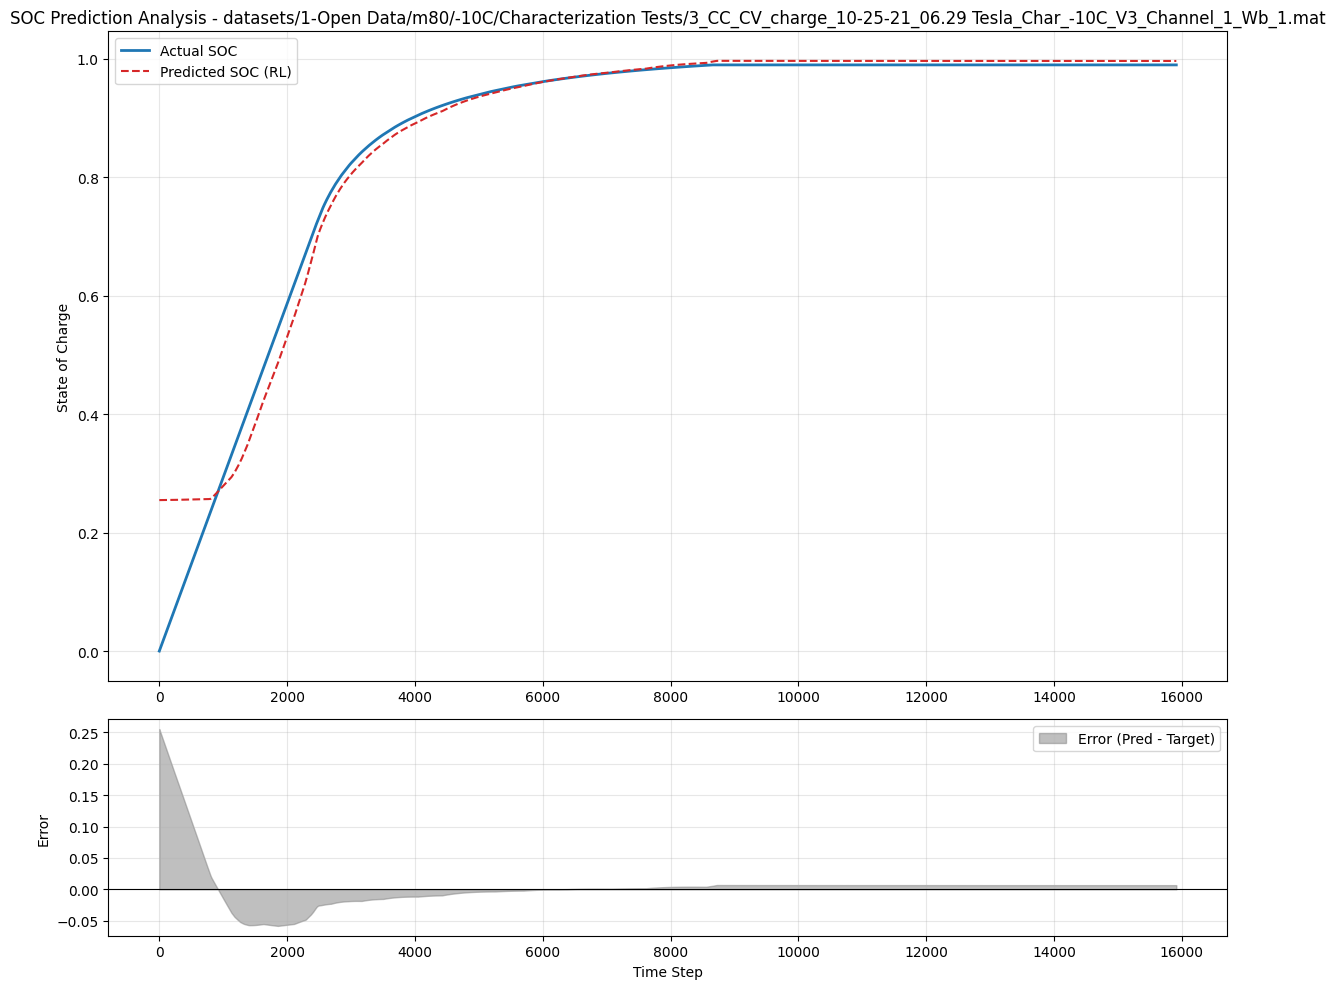

{'mae': np.float64(0.017392626126619036),
 'rmse': np.float64(0.03859667931530256),
 'mape': np.float64(56.63596448764423),
 'r2': 0.9735212393215351}

In [28]:
evaluate_model(DDPG_model, df_test)

# Twin Delayed Deep Deterministic Policy Gradient

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
INFO: Model learn starting...
INFO: Model learn finished
INFO: Evaluating Session: datasets/1-Open Data/m80/25C/Drive Cycles/12_REORDERED2_06-07-21_08.52 Tesla_25C_DriveCycles_Ch1.mat ---
MAE   : 0.00000
RMSE  : 0.00000
MAPE  : 0.00%
R2    : 1.00000


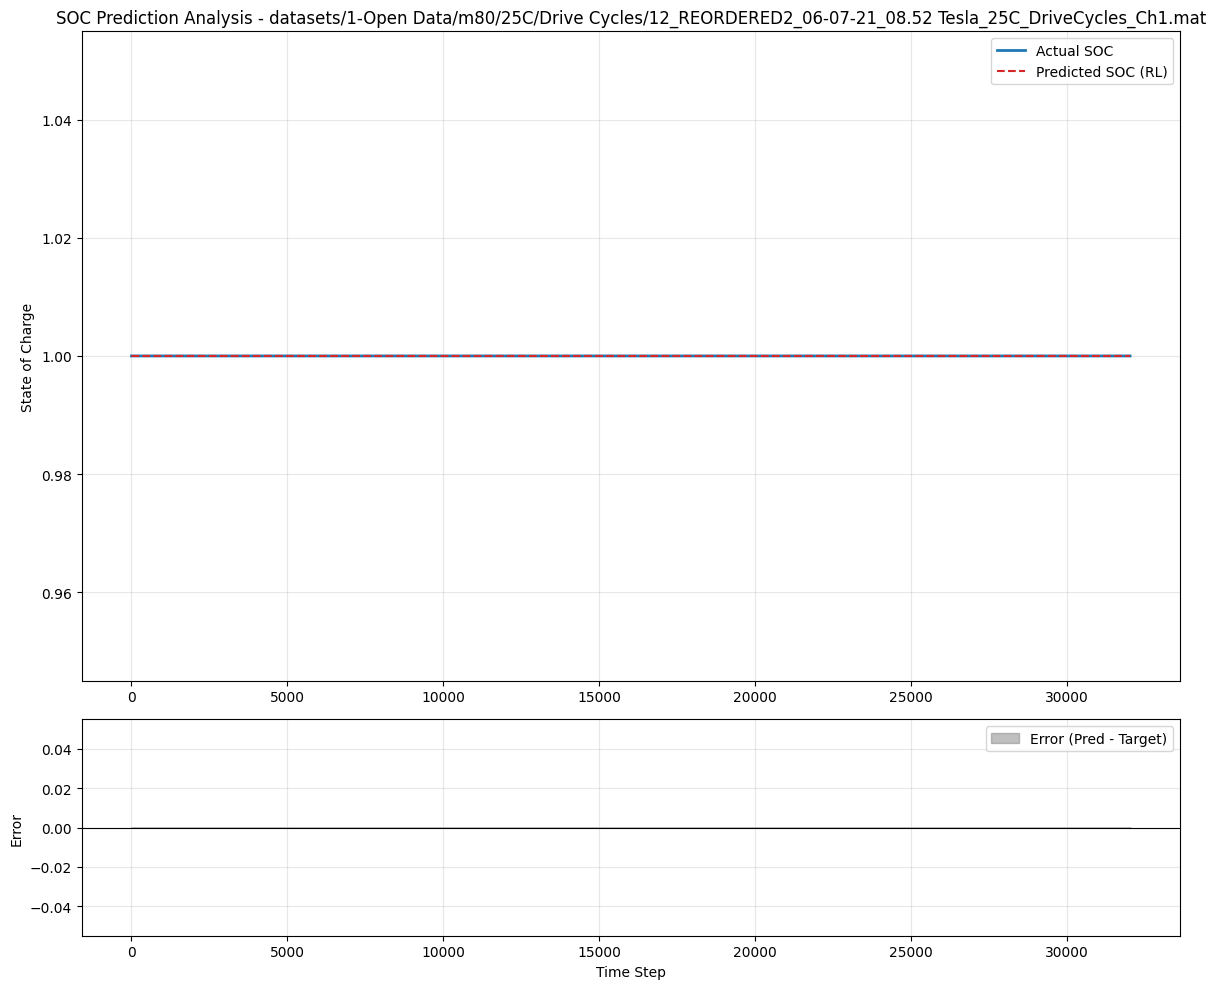

{'mae': np.float64(0.0),
 'rmse': np.float64(0.0),
 'mape': np.float64(0.0),
 'r2': 1.0}

In [27]:
TD3_model = TD3(
    "MlpPolicy", 
    env, 
    action_noise=action_noise,
    verbose=1, 
    learning_rate=0.001,
    buffer_size=100000,
    batch_size=100,       # TD3 biasanya bekerja baik dengan batch size sedikit lebih besar
    tau=0.005,
    gamma=0.99,
    policy_delay=2,       # Parameter khas TD3: Update policy setiap 2 kali update critic
    target_policy_noise=0.2, # Noise tambahan untuk target smoothing
    target_noise_clip=0.5
)

print("INFO: Model learn starting...")
TD3_model.learn(total_timesteps=100000)
TD3_model.save("td3_soc_battery")
print("INFO: Model learn finished")
evaluate_model(TD3_model, df_test)

# Soft Actor Critic

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
INFO: SAC Model learn starting...
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 2.28e+04  |
|    ep_rew_mean     | -1.62e+03 |
| time/              |           |
|    episodes        | 4         |
|    fps             | 131       |
|    time_elapsed    | 694       |
|    total_timesteps | 91214     |
| train/             |           |
|    actor_loss      | 11.7      |
|    critic_loss     | 0.000152  |
|    ent_coef        | 0.0576    |
|    ent_coef_loss   | 0.0078    |
|    learning_rate   | 0.001     |
|    n_updates       | 91113     |
----------------------------------
INFO: SAC Model learn finished
INFO: Evaluating Session: datasets/1-Open Data/m80/25C/Drive Cycles/17_CC_CV_charge_06-09-21_04.02 Tesla_25C_DriveCycles_Ch1.mat ---
MAE   : 0.05153
RMSE  : 0.05839
MAPE  : 6.76%
R2    : 0.90828


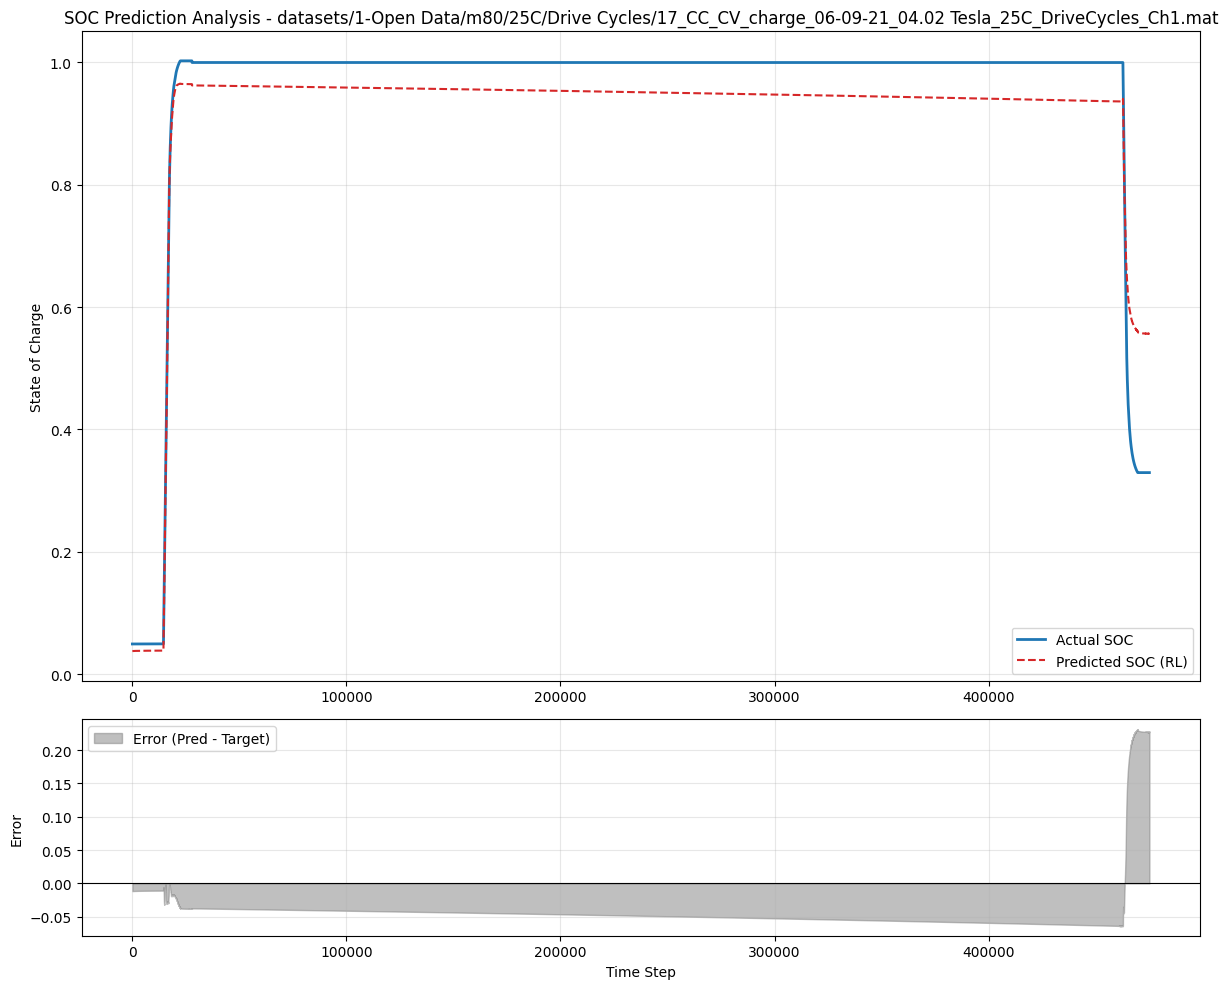

{'mae': np.float64(0.05152635823315956),
 'rmse': np.float64(0.05839240490076526),
 'mape': np.float64(6.760304601000025),
 'r2': 0.9082847695406958}

In [28]:
from stable_baselines3 import SAC

# Catatan: SAC biasanya tidak membutuhkan 'action_noise' eksternal karena memiliki 
# mekanisme entropy tuning otomatis untuk eksplorasi.

SAC_model = SAC(
    "MlpPolicy",
    env,
    verbose=1,
    learning_rate=0.001,
    buffer_size=100000,
    batch_size=100,       
    tau=0.005,
    gamma=0.99,
    # Parameter khas SAC:
    ent_coef="auto",      # Mengoptimalkan entropi secara otomatis
    train_freq=1,         # Update setiap langkah
    gradient_steps=1,     # Berapa kali gradient update per step
    use_sde=False,        # State Dependent Exploration (bisa True untuk kontrol robotik halus)
)

print("INFO: SAC Model learn starting...")
SAC_model.learn(total_timesteps=100000)
SAC_model.save("sac_soc_battery")
print("INFO: SAC Model learn finished")

evaluate_model(SAC_model, df_test)

# Proximal Policy Optimization

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Memulai Training...
-----------------------------
| time/              |      |
|    fps             | 543  |
|    iterations      | 1    |
|    time_elapsed    | 3    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 750         |
|    iterations           | 2           |
|    time_elapsed         | 5           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.019186173 |
|    clip_fraction        | 0.233       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.44       |
|    explained_variance   | 6e-05       |
|    learning_rate        | 0.0003      |
|    loss                 | 0.551       |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0302     |
|   

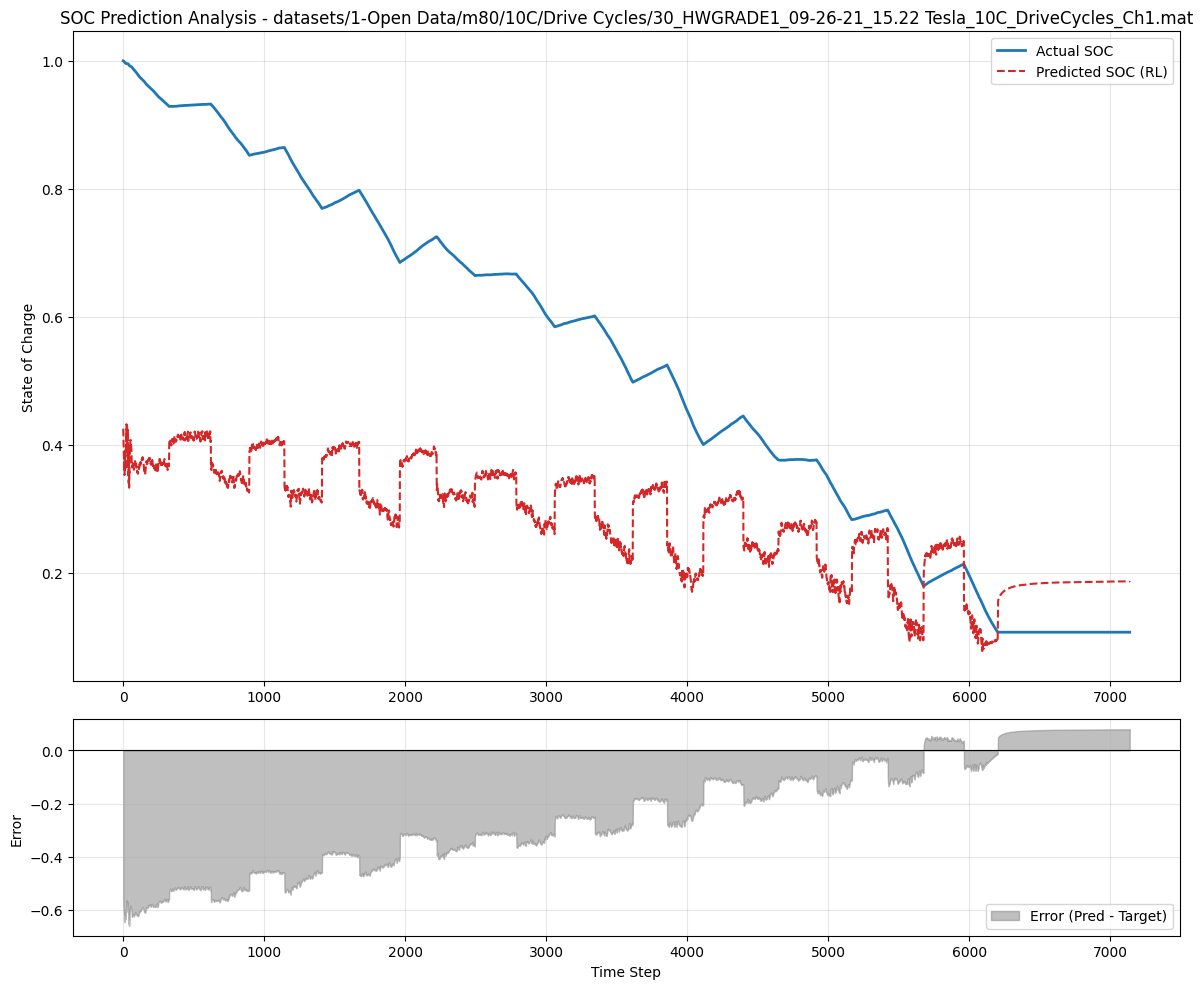

{'mae': np.float64(0.26272387094850164),
 'rmse': np.float64(0.31565122145373076),
 'mape': np.float64(48.88931542031087),
 'r2': -0.30961120055219915}

In [29]:
PPO_model = PPO("MlpPolicy", env, verbose=1, learning_rate=0.0003)

print("Memulai Training...")
PPO_model.learn(total_timesteps=100000)
PPO_model.save("ppo_soc_battery")

evaluate_model(PPO_model, df_test)

# Trust Region Proximal Optimization

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Memulai Training...
-----------------------------
| time/              |      |
|    fps             | 559  |
|    iterations      | 1    |
|    time_elapsed    | 3    |
|    total_timesteps | 2048 |
-----------------------------
----------------------------------------
| time/                     |          |
|    fps                    | 830      |
|    iterations             | 2        |
|    time_elapsed           | 4        |
|    total_timesteps        | 4096     |
| train/                    |          |
|    explained_variance     | 0        |
|    is_line_search_success | 1        |
|    kl_divergence_loss     | 0.00984  |
|    learning_rate          | 0.0003   |
|    n_updates              | 1        |
|    policy_objective       | 0.0369   |
|    std                    | 1.01     |
|    value_loss             | 69.6     |
----------------------------------------
--------------------

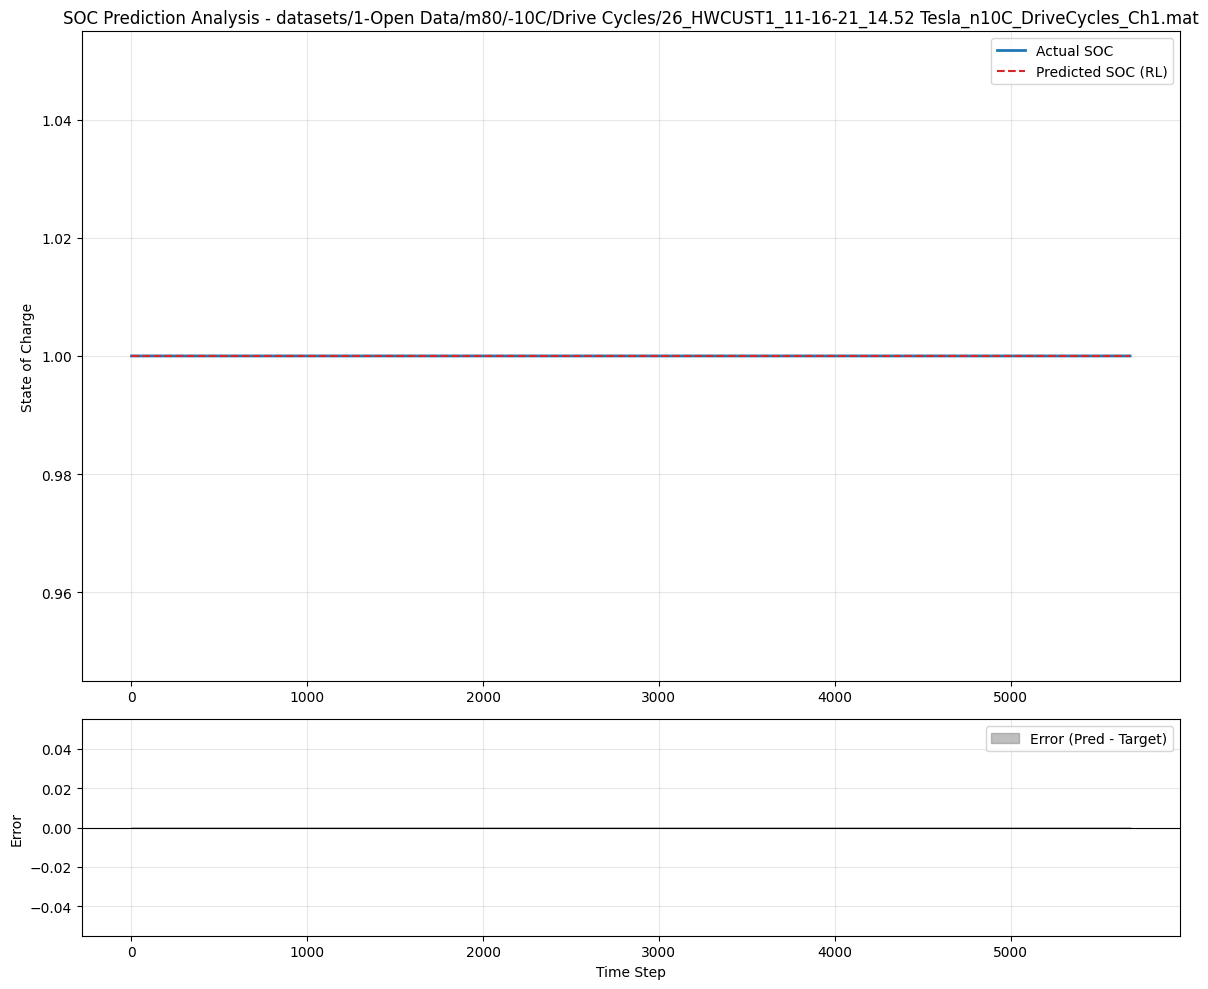

{'mae': np.float64(0.0),
 'rmse': np.float64(0.0),
 'mape': np.float64(0.0),
 'r2': 1.0}

In [30]:
TRPO_model = TRPO("MlpPolicy", env, verbose=1, learning_rate=0.0003)

print("Memulai Training...")
TRPO_model.learn(total_timesteps=100000)
TRPO_model.save("trpo_soc_battery")

evaluate_model(TRPO_model, df_test)